In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 


In [14]:
df = sns.load_dataset("iris")
print("5 dòng đầu tiên:")
print(df.head())
print("\nThông tin dữ liệu:")
df.info() 

5 dòng đầu tiên:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Thống kê cơ bản
stats_summary = df.describe()

# Tính IQR (Q3 - Q1)
stats_summary.loc['iqr'] = stats_summary.loc['75%'] - stats_summary.loc['25%']

# Tính Mode (Yếu vị) 
print("Mode của các biến số:")
display(df.select_dtypes(include=[np.number]).mode().iloc[0])

print("\nBảng thống kê đầy đủ:")
display(stats_summary)

Mode của các biến số:


sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64


Bảng thống kê đầy đủ:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
iqr,1.300000,0.500000,3.500000,1.500000


In [16]:
grouped = df.groupby('species').agg(['mean', 'std'])
display(grouped)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

###  Nhận xét (Phần 1 - Câu 3)

Dựa trên bảng thống kê `mean` và `std` theo từng nhóm, loài **`setosa`** là nhóm có sự khác biệt rõ rệt và dễ phân biệt nhất so với hai loài còn lại:

*   **Đặc trưng cánh hoa (Petal):** Loài `setosa` có kích thước cánh hoa cực kỳ nhỏ với chiều dài trung bình (`petal_length`) chỉ **1.46 cm** và chiều rộng (`petal_width`) là **0.25 cm**, tách biệt hoàn toàn so với hai loài còn lại (đều có kích thước lớn hơn gấp nhiều lần).
*   **Đặc trưng đài hoa (Sepal):** `setosa` có đài hoa ngắn nhất (`sepal_length` ~ **5.01 cm**) nhưng lại có bề ngang rộng nhất (`sepal_width` ~ **3.43 cm**).
*   **Độ ổn định (std):** Độ lệch chuẩn các chỉ số của `setosa` (đặc biệt là phần cánh hoa) rất thấp, cho thấy các cá thể thuộc loài này có kích thước rất đồng đều, ít bị biến động hơn so với `versicolor` và `virginica`.

**Kết luận:** Loài `setosa` mang đặc tính hình thái hoàn toàn khác biệt, trong khi `versicolor` và `virginica` có xu hướng gần cận và giao thoa với nhau nhiều hơn.


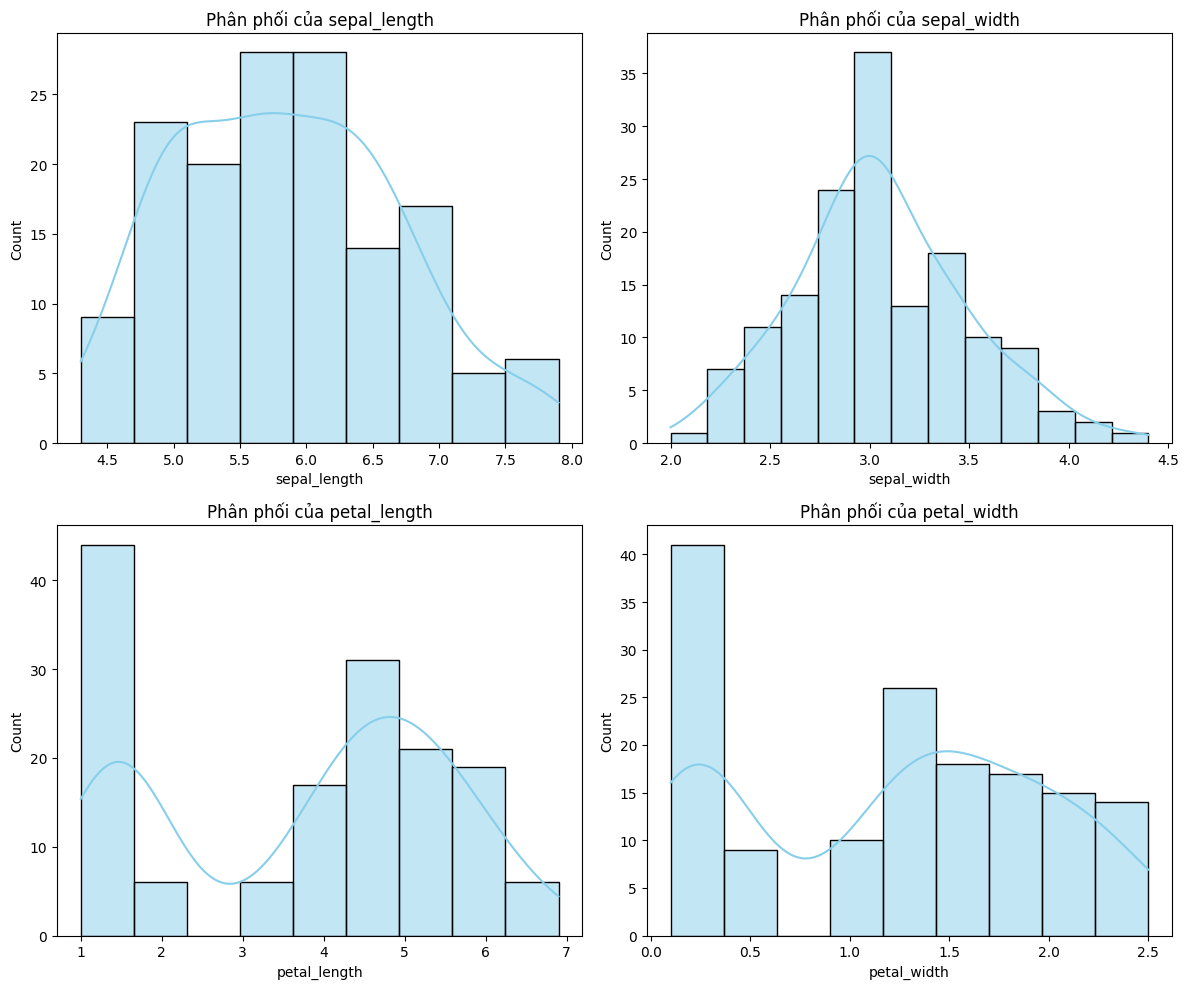

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = df.columns[:-1]

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2], color='skyblue')
    axes[i//2, i%2].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

###  Nhận xét (Phần 2 - Câu 1)

Dựa trên biểu đồ Histogram kết hợp đường cong ước lượng mật độ nhân (KDE) của 4 biến số, ta có các nhận xét về hình dạng phân phối như sau:

1. **`sepal_length` (Chiều dài đài hoa):**
   * **Hình dạng:** Phân phối hơi lệch phải nhẹ (tích lũy nhiều ở các giá trị từ 5.0 đến 6.5 và kéo một đuôi ngắn về phía các giá trị lớn 7.5 - 8.0).
   * **Đánh giá:** Nhìn chung gần đối xứng và có dạng một đỉnh lớn, có thể xem là gần chuẩn (gần phân phối chuẩn).

2. **`sepal_width` (Chiều rộng đài hoa):**
   * **Hình dạng:** Phân phối đối xứng rất tốt xung quanh giá trị trung bình (khoảng 3.0). Đường cong KDE có dạng hình chuông chuẩn mực với một đỉnh duy nhất rõ rệt.
   * **Đánh giá:** Biến số này có dạng **gần với phân phối chuẩn nhất** trong cả 4 biến số.

3. **`petal_length` (Chiều dài cánh hoa) & `petal_width` (Chiều rộng cánh hoa):**
   * **Hình dạng:** Cả hai biến này đều thể hiện phân phối rõ rệt dạng **nhiều đỉnh (bimodal/multimodal - cụ thể là 2 đỉnh)**.
   * **Đánh giá:** Có một khoảng trống (bị trũng xuống hẳn) ở giữa dữ liệu (đối với `petal_length` là khoảng 2.0 - 3.0, đối với `petal_width` là khoảng 0.5 - 1.0). Điều này xảy ra do sự khác biệt quá lớn về kích thước cánh hoa giữa loài `setosa` (nhóm nhỏ bên trái) và hai loài còn lại (nhóm lớn bên phải), tạo thành hai cụm phân phối riêng biệt trên cùng một đồ thị chung.


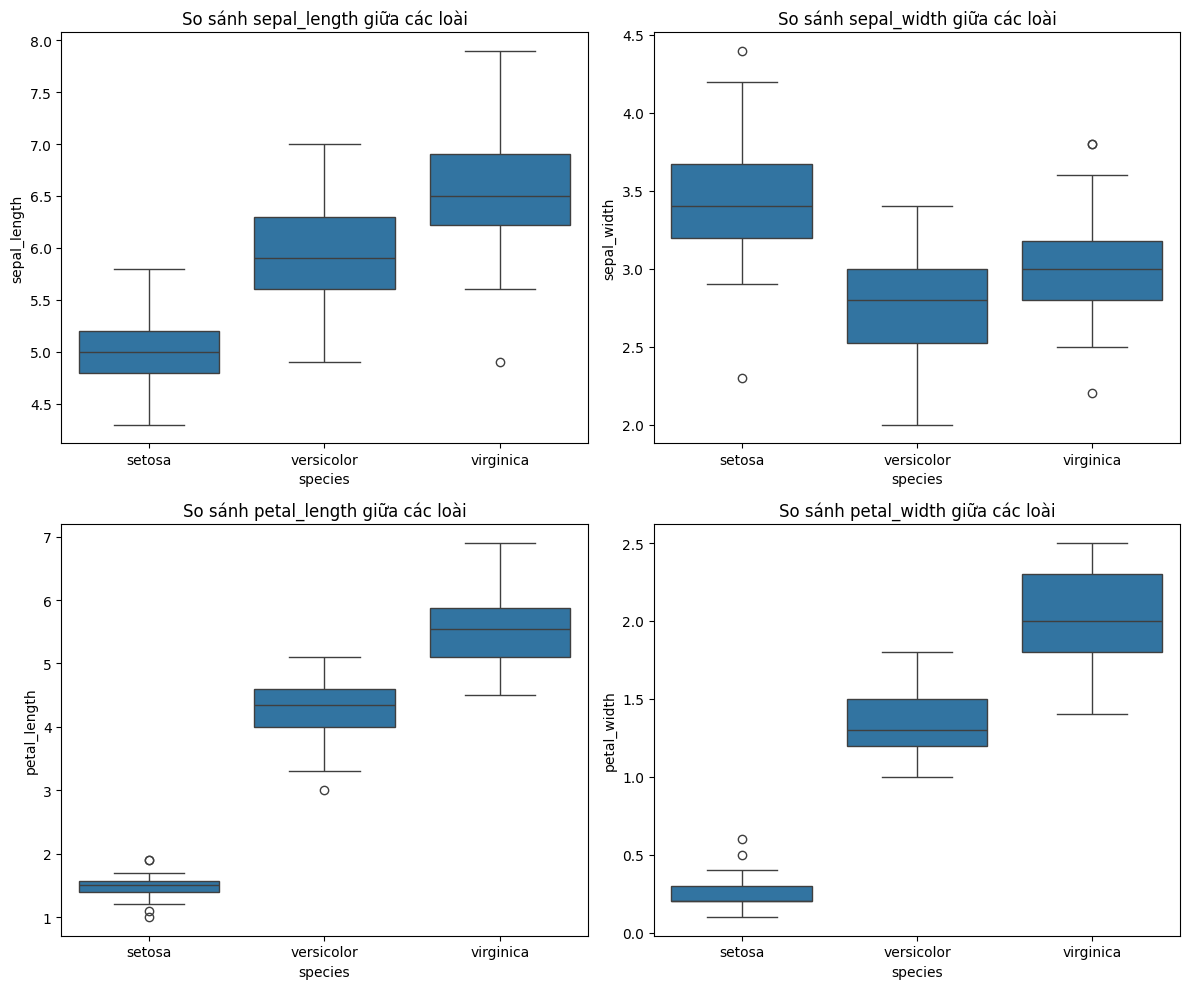

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(features):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'So sánh {col} giữa các loài')

plt.tight_layout()
plt.show()

###  Nhận xét (Phần 2 - Câu 2)

Dựa trên các biểu đồ Boxplot so sánh 4 biến số giữa 3 loài hoa (`setosa`, `versicolor`, `virginica`), ta có các nhận xét sau:

1. **Sự khác biệt về kích thước tổng thể:**
   * Loài **`virginica`** luôn có kích thước lớn nhất ở các biến `sepal_length`, `petal_length`, và `petal_width`.
   * Ngược lại, loài **`setosa`** có kích thước nhỏ nhất ở 3 biến kể trên, nhưng lại sở hữu chiều rộng đài hoa (`sepal_width`) lớn nhất vượt trội so với hai loài kia.
   * Loài **`versicolor`** luôn nằm ở vị trí trung gian (giữa `setosa` và `virginica`) đối với hầu hết các chỉ số.

2. **Khả năng phân loại dựa trên đặc trưng:**
   * **Đặc trưng Cánh hoa (`petal_length` và `petal_width`):** Cho thấy sự phân tách cực kỳ rõ ràng giữa các loài. Hộp dữ liệu của `setosa` hoàn toàn tách biệt, không hề bị chồng lấn với `versicolor` hay `virginica`. Điều này giải thích cho hiện tượng phân phối "nhiều đỉnh" đã thấy ở biểu đồ Histogram trước đó và cho thấy đặc trưng cánh hoa là tiêu chí tốt nhất để phân biệt loài.
   * **Đặc trưng Đài hoa (`sepal_length` và `sepal_width`):** Các hộp dữ liệu có sự giao thoa, chồng lấn lên nhau khá nhiều (đặc biệt là giữa `versicolor` và `virginica`), khiến việc phân biệt hai loài này dựa trên đài hoa khó khăn hơn.

3. **Giá trị ngoại lai (Outliers):**
   * Xuất hiện rải rác các điểm ngoại lai (các chấm tròn nằm ngoài râu của hộp) ở một số nhóm:
     * `sepal_length`: Xuất hiện 1 điểm ngoại lai thấp ở loài `virginica`.
     * `sepal_width`: Xuất hiện ngoại lai ở cả loài `setosa` (cả phía trên và dưới) và `virginica` (phía dưới).
     * `petal_length`: Xuất hiện ngoại lai ở loài `setosa` và `versicolor`.
     * `petal_width`: Xuất hiện một vài điểm ngoại lai phía trên ở loài `setosa`.


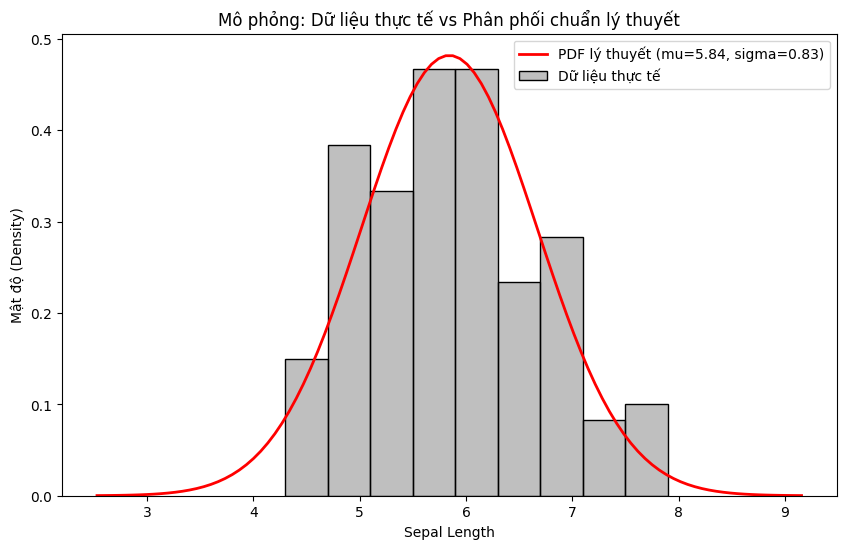

In [20]:
# Bước 1: Chọn biến 'sepal_length' để làm mẫu
data = df['sepal_length']
mu = data.mean()
sigma = data.std()

# Bước 2: Sinh mẫu ngẫu nhiên từ phân phối Normal có cùng mean và std
samples = np.random.normal(mu, sigma, 1000)

# Bước 3: Vẽ đồ thị
plt.figure(figsize=(10, 6))

# Vẽ histogram dữ liệu thực tế (dạng mật độ - density)
sns.histplot(data, stat="density", kde=False, label='Dữ liệu thực tế', color='gray', alpha=0.5)

# Vẽ đường PDF lý thuyết của phân phối chuẩn
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
pdf = stats.norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', lw=2, label=f'PDF lý thuyết (mu={mu:.2f}, sigma={sigma:.2f})')

plt.title("Mô phỏng: Dữ liệu thực tế vs Phân phối chuẩn lý thuyết")
plt.xlabel("Sepal Length")
plt.ylabel("Mật độ (Density)")
plt.legend()
plt.show()

###  Nhận xét (Phần 2 - Câu 3)

Dựa trên biểu đồ so sánh giữa phân phối thực tế của biến `sepal_length` (các cột màu xám) và đường cong mật độ xác suất PDF lý thuyết theo phân phối chuẩn $N(5.84, 0.83^2)$ (đường màu đỏ), ta có các đánh giá về mức độ khớp như sau:

1. **Mức độ khớp tổng thể (Goodness of Fit):**
   * **Đánh giá:** Dữ liệu thực tế và đường PDF lý thuyết có **mức độ khớp tương đối cao (khớp khá tốt)**.
   * **Chi tiết:** Đường cong lý thuyết hình chuông bao bọc và bám rất sát theo hình dáng phân bổ chung của các cột histogram thực tế. Khu vực tập trung mật độ cao nhất của dữ liệu thực tế (vùng đỉnh quanh giá trị trung bình từ 5.5 đến 6.5) hoàn toàn trùng khớp với đỉnh cao nhất của đường PDF lý thuyết ($\mu = 5.84$).

2. **Các điểm sai lệch nhỏ (Discrepancies):**
   * Mặc dù khớp tốt ở xu hướng chung, dữ liệu thực tế vẫn có một vài điểm không hoàn toàn mượt mà như lý thuyết do giới hạn của kích thước mẫu:
     * **Vùng từ 4.7 đến 5.1:** Biểu đồ thực tế bị nhô cao lên một chút so với đường lý thuyết (dữ liệu tập trung dày hơn kỳ vọng).
     * **Vùng từ 5.1 đến 5.5:** Biểu đồ thực tế bị trũng nhẹ xuống thấp hơn một chút so với đường cong lý thuyết.
     * **Vùng đuôi bên phải (từ 7.5 đến 8.0):** Có một nhóm nhỏ dữ liệu thực tế nhô lên, tạo thành một chiếc đuôi hơi dày hơn so với đường PDF lý thuyết vốn tiệm cận dần về 0.

**Kết luận:** Sự sai lệch nhỏ này hoàn toàn bình thường trong thống kê thực nghiệm. Biến số `sepal_length` của tập dữ liệu này hoàn toàn đủ điều kiện để áp dụng các mô hình giả định phân phối chuẩn (Normal Distribution).


In [23]:
# 1. Lấy các cột dữ liệu số
numeric_df = df.select_dtypes(include=[np.number])

# 2. Tính và hiển thị ma trận hiệp phương sai
cov_matrix = numeric_df.cov()
print("Ma trận Hiệp phương sai (Covariance):")
display(cov_matrix)

# 3. Tính và hiển thị ma trận tương quan
corr_matrix = numeric_df.corr()
print("\nMa trận Tương quan (Correlation):")
display(corr_matrix)




Ma trận Hiệp phương sai (Covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



Ma trận Tương quan (Correlation):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


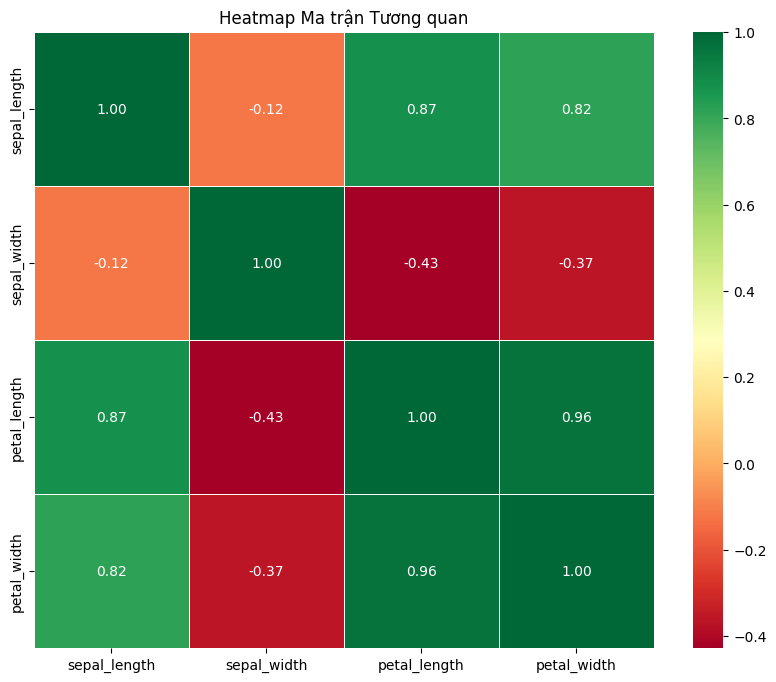

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Ma trận Tương quan")
plt.show()

###  Nhận xét (Phần 3 - Câu 2)

Dựa trên biểu đồ nhiệt Ma trận tương quan (Correlation Heatmap), ta có các phân tích sau về mối quan hệ giữa các cặp biến:

1. **Cặp biến có tương quan mạnh nhất:**
   * Cặp biến **`petal_length` (Chiều dài cánh hoa) và `petal_width` (Chiều rộng cánh hoa)** có hệ số tương quan tuyến tính mạnh nhất với giá trị cực kỳ cao lên tới **0.96**.
   * **Ý nghĩa:** Đây là mối tương quan thuận (đồng biến) gần như hoàn hảo. Khi chiều dài cánh hoa tăng thì chiều rộng cánh hoa cũng tăng theo tỷ lệ tương ứng rất đồng đều.
   * Kế tiếp là cặp `sepal_length` và `petal_length` (**0.87**), cùng cặp `sepal_length` và `petal_width` (**0.82**) cũng thể hiện tương quan thuận rất mạnh (màu xanh đậm).

2. **Dấu hiệu Đa cộng tuyến (Multicollinearity):**
   * **Đánh giá:** Trong tập dữ liệu này **có dấu hiệu đa cộng tuyến rất rõ rệt**.
   * **Chi tiết:** Trong thống kê và học máy, hiện tượng đa cộng tuyến thường được ghi nhận khi hệ số tương quan giữa hai biến độc lập vượt quá ngưỡng **0.70** hoặc **0.80**. Ở đây, ba cặp biến liên quan đến `petal_length`, `petal_width` và `sepal_length` đều có hệ số tương quan rất cao (**0.96**, **0.87**, và **0.82**).
   * **Hệ quả:** Nếu sử dụng đồng thời cả 4 biến số này làm biến độc lập để xây dựng các mô hình hồi quy (ví dụ: Linear Regression) nhằm dự đoán một biến mục tiêu khác, hiện tượng đa cộng tuyến này sẽ làm nhiễu dữ liệu, khiến sai số của các hệ số hồi quy tăng cao và mô hình trở nên kém ổn định.


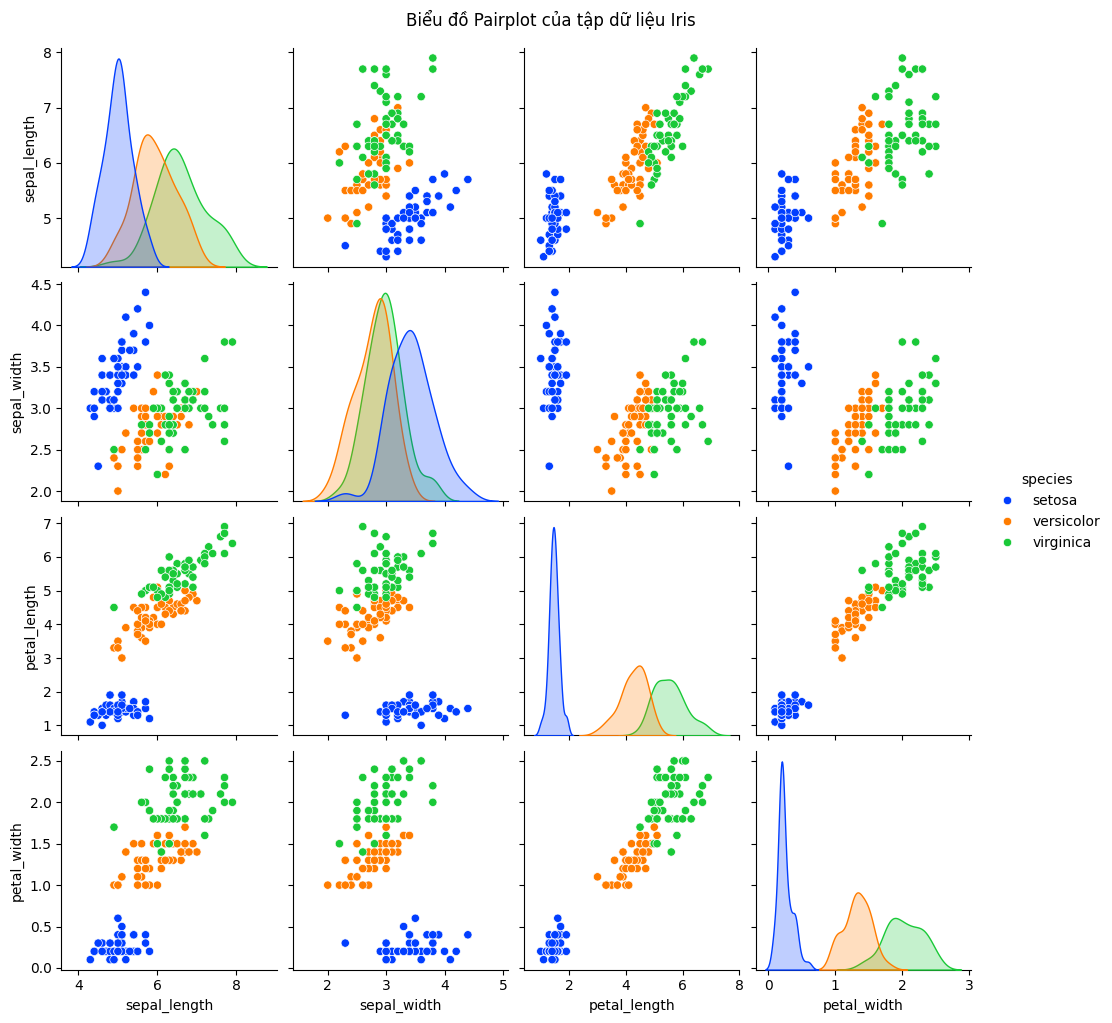

In [25]:
# Vẽ pairplot tô màu theo loài (species)
sns.pairplot(df, hue='species', diag_kind='kde', palette='bright')
plt.suptitle("Biểu đồ Pairplot của tập dữ liệu Iris", y=1.02)
plt.show()

###  Nhận xét (Phần 3 - Câu 3)

Dựa trên biểu đồ Pairplot được phân tách màu sắc theo 3 loài (`setosa` - màu xanh dương, `versicolor` - màu cam, `virginica` - màu xanh lá), ta có các nhận xét sau về mối quan hệ giữa các biến:

1. **Sự phân tách giữa các loài hoa (Phân cụm):**
   * **Loài `setosa`:** Hoàn toàn tách biệt thành một cụm riêng biệt trên mọi biểu đồ phân tán (Scatter plot) liên quan đến thuộc tính cánh hoa (`petal_length`, `petal_width`). Điều này chứng tỏ loài `setosa` có đặc tính hình thái hoàn toàn độc lập và cực kỳ dễ phân loại.
   * **Loài `versicolor` và `virginica`:** Các điểm dữ liệu có xu hướng nằm gần nhau và có sự giao thoa, chồng lấn nhẹ ở các vùng biên. Tuy nhiên, chúng vẫn tạo thành hai cụm xu hướng tuyến tính khá rõ ràng, đặc biệt là trên các biểu đồ phân tán giữa kích thước cánh hoa và đài hoa.

2. **Mối quan hệ tuyến tính giữa các cặp biến:**
   * **Tương quan đồng biến rất mạnh:** Các cặp biến như `petal_length` vs `petal_width`, `sepal_length` vs `petal_length`, và `sepal_length` vs `petal_width` hiển thị các đám mây điểm kéo dài theo một đường thẳng dốc lên từ trái sang phải. Khi một biến tăng, biến còn lại cũng tăng theo rõ rệt ở cả 3 loài.
   * **Tương quan yếu hoặc không rõ ràng:** Biến `sepal_width` khi kết hợp với các biến khác (như `sepal_length`, `petal_length`) tạo thành các đám mây điểm phân tán rộng, không có hình dáng đường thẳng rõ rệt. Điều này cho thấy chiều rộng đài hoa ít có mối quan hệ tuyến tính với các đặc trưng còn lại.

3. **Hình dáng đường mật độ (Đường chéo chính):**
   * Các biểu đồ trên đường chéo chính cho thấy phân phối của riêng từng biến theo từng nhóm loài. 
   * Một lần nữa, đường cong của loài `setosa` (màu xanh dương) ở hai biến `petal_length` và `petal_width` đứng độc lập hoàn toàn, trong khi hai đường cong của `versicolor` và `virginica` gối lên nhau một phần, minh chứng cho việc kích thước cánh hoa là đặc trưng vàng để phân biệt các loài này.


In [26]:
# 1. Khai báo các xác suất ban đầu
P_B = 0.01          # Tỉ lệ mắc bệnh trong dân số (Prior)
P_pos_given_B = 0.99  # Độ nhạy (Sensitivity)
P_pos_given_notB = 0.05 # Tỉ lệ dương tính giả (False Positive Rate)

# 2. Tính P(B ngang) - Tỉ lệ không mắc bệnh
P_notB = 1 - P_B

# 3. Tính P(+) - Xác suất có kết quả dương tính (Sử dụng công thức xác suất đầy đủ)
P_pos = P_pos_given_B * P_B + P_pos_given_notB * P_notB

# 4. Tính P(B|+) - Xác suất thực sự mắc bệnh khi có kết quả (+) (Định lý Bayes)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất thực sự mắc bệnh sau khi xét nghiệm dương tính là: {P_B_given_pos:.4f}")

Xác suất thực sự mắc bệnh sau khi xét nghiệm dương tính là: 0.1667


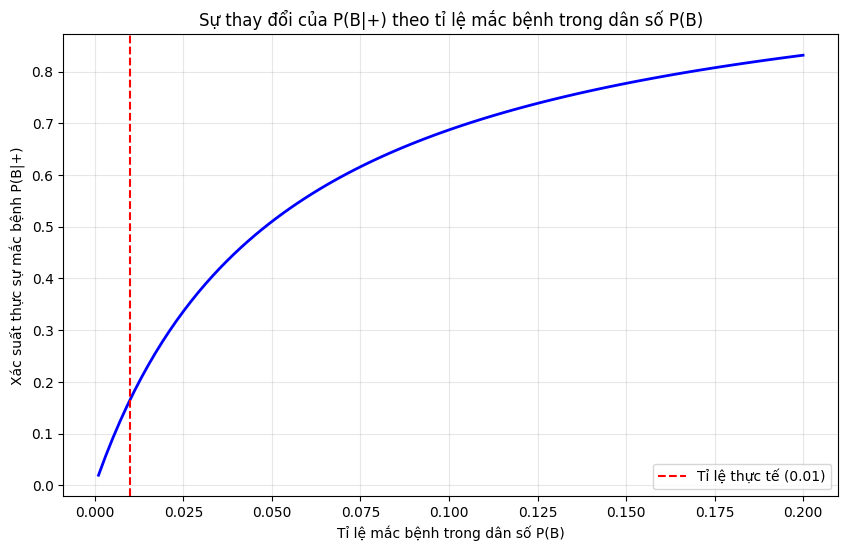

In [27]:
# Tạo dải tỉ lệ mắc bệnh từ 0.001 đến 0.2
p_b_range = np.linspace(0.001, 0.2, 100)

# Hàm tính Bayes
def calculate_posterior(p_prior):
    p_pos = (P_pos_given_B * p_prior) + (P_pos_given_notB * (1 - p_prior))
    return (P_pos_given_B * p_prior) / p_pos

# Tính toán các giá trị hậu nghiệm tương ứng
posteriors = [calculate_posterior(p) for p in p_b_range]

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(p_b_range, posteriors, color='blue', lw=2)
plt.axvline(x=0.01, color='red', linestyle='--', label='Tỉ lệ thực tế (0.01)')
plt.title("Sự thay đổi của P(B|+) theo tỉ lệ mắc bệnh trong dân số P(B)")
plt.xlabel("Tỉ lệ mắc bệnh trong dân số P(B)")
plt.ylabel("Xác suất thực sự mắc bệnh P(B|+)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

###  Nhận xét & Giải thích (Phần 4 - Câu 2)

Dựa trên đồ thị khảo sát sự thay đổi của xác suất thực sự mắc bệnh $P(B|+)$ theo tỷ lệ mắc bệnh trong dân số $P(B)$, ta có các nhận xét và giải thích khoa học sau:

#### 1. Nhận xét xu hướng đồ thị
* **Tỷ lệ thuận phi tuyến tính:** Khi tỷ lệ mắc bệnh trong cộng đồng $P(B)$ tăng lên, xác suất một người thực sự có bệnh sau khi nhận kết quả dương tính $P(B|+)$ cũng **tăng mạnh theo đường cong**.
* **Tại vị trí tỷ lệ thực tế ($P(B) = 0.01$):** Đường đứt nét màu đỏ cho thấy xác suất thực sự mắc bệnh $P(B|+)$ ở mức **rất thấp (chỉ khoảng dưới 20%)**, mặc dù xét nghiệm có độ chính xác cao.

#### 2. Giải thích hiện tượng "Phản trực giác" khi bệnh hiếm
Hiện tượng kết quả dương tính nhưng xác suất thực mắc bệnh lại rất thấp khi bệnh hiếm gọi là **Nghịch lý xét nghiệm (False Positive Paradox)**. Kết quả này gây "phản trực giác" (người dân thường nghĩ dương tính nghĩa là chắc chắn 99% mắc bệnh) vì những lý do sau:

* **Sự áp đảo của số ca Dương tính giả (False Positives):** Khi một căn bệnh cực kỳ hiếm gặp trong cộng đồng (ví dụ chỉ $1\%$), số lượng người khỏe mạnh sẽ chiếm đại đa số ($99\%$). Dù xét nghiệm có độ đặc hiệu rất cao (ví dụ $95\%$), thì $5\%$ sai số dương tính giả của một nhóm người khỏe mạnh khổng lồ vẫn sẽ cho ra một **số lượng ca dương tính giả lớn hơn rất nhiều** so với số ca dương tính thật từ nhóm người bệnh ít ỏi.
* **Bản chất của công thức Bayes:** Xác suất $P(B|+)$ được tính bằng tỷ lệ:
  $$P(B|+) = \frac{\text{Số ca Dương tính thật}}{\text{Số ca Dương tính thật} + \text{Số ca Dương tính giả}}$$
  Khi bệnh hiếm, mẫu số bị phình to do lượng "Dương tính giả" quá lớn, khiến cho phân số này giảm mạnh.

**Kết luận:** Đồ thị chứng minh rằng đối với các căn bệnh hiếm, một kết quả xét nghiệm sàng lọc dương tính ban đầu chưa đủ để kết luận mắc bệnh. Bác sĩ luôn cần chỉ định thêm các xét nghiệm chuyên sâu thứ hai (confirmatory test) để loại bỏ hiện tượng dương tính giả này.


In [34]:
import numpy as np
import pandas as pd

# 1. Định nghĩa bộ từ điển xác suất lý thuyết
prob_words_spam = {
    'free': 0.5, 'money': 0.4, 'winner': 0.3, 'offer': 0.4, 
    'click': 0.5, 'gift': 0.2, 'prize': 0.5, 'urgent': 0.4, 
    'promotion': 0.3, 'investment': 0.3, 'guaranteed': 0.2
}

prob_words_ham = {
    'free': 0.05, 'money': 0.01, 'winner': 0.01, 'offer': 0.05, 
    'click': 0.02, 'gift': 0.01, 'prize': 0.01, 'urgent': 0.05,
    'meeting': 0.4, 'project': 0.3, 'discuss': 0.3, 'schedule': 0.2,
    'hello': 0.5, 'thanks': 0.4, 'attached': 0.2, 'team': 0.3,
    'review': 0.2, 'document': 0.2, 'regards': 0.3
}

P_spam = 0.5
P_ham = 0.5

# 2. Hàm phân loại chuẩn hóa thuật toán Naive Bayes
def classify_email_final(sentence):
    words = sentence.lower().split()
    p_s = P_spam
    p_h = P_ham
    found_keywords = []

    for word in words:
        # Làm sạch các dấu câu ở đầu và cuối từ
        clean_word = word.strip('!?,.:;()""\'\'') 
        
        # CHỈ TÍNH toán nếu từ đó tồn tại trong ít nhất 1 trong 2 từ điển
        if clean_word in prob_words_spam or clean_word in prob_words_ham:
            found_keywords.append(clean_word)
            
            p_s *= prob_words_spam.get(clean_word, 0.05)
            p_h *= prob_words_ham.get(clean_word, 0.05)
            
    if not found_keywords:
        return P_spam / (P_spam + P_ham), ["Không có từ khóa"]
        
    prob_is_spam = p_s / (p_s + p_h)
    return prob_is_spam, found_keywords

test_emails_v2 = [
    "URGENT: Your prize money is waiting! Click here for your free investment gift and promotion winner!",
    "Guaranteed money return now! Click this link for a special investment offer",
    "Hi team, attached is the project review document for our meeting. Please discuss the schedule. Regards.",
    "Hello, I have reviewed the project document. Let's schedule a team meeting to discuss further. Thanks.",
    "Are you free for the project meeting? I need to review the budget money for the team.",
    "Urgent: We need to discuss the promotion schedule for the free gift project.",
    "Hi, thanks for the gift! It was very kind of you. See you at the meeting tomorrow.",
    "Best regards, please find the attached schedule for your review.",
    "The weather is very nice today, let's go for a walk in the park."
]

results = []
for email in test_emails_v2:
    prob, keywords = classify_email_final(email)
    results.append({
        "Nội dung Email": email if len(email) <= 65 else email[:62] + "...",
        "Từ khóa tìm thấy": ", ".join(keywords),
        "Xác suất SPAM": f"{prob:.4f}",
        "Kết luận": "SPAM " if prob > 0.8 else "HAM "
    })

df_results = pd.DataFrame(results)
display(df_results)


,Nội dung Email,Từ khóa tìm thấy,Xác suất SPAM,Kết luận
0,URGENT: Your prize money is waiting! Click her...,"urgent, prize, money, click, free, investment,...",1.0000,SPAM
1,Guaranteed money return now! Click this link f...,"guaranteed, money, click, investment, offer",1.0000,SPAM
2,"Hi team, attached is the project review docume...","team, attached, project, review, document, mee...",0.0000,HAM
3,"Hello, I have reviewed the project document. L...","hello, project, document, schedule, team, meet...",0.0000,HAM
4,Are you free for the project meeting? I need t...,"free, project, meeting, review, money, team",0.2577,HAM
5,Urgent: We need to discuss the promotion sched...,"urgent, discuss, promotion, schedule, free, gi...",0.9852,SPAM
6,"Hi, thanks for the gift! It was very kind of y...","thanks, gift, meeting",0.2381,HAM
7,"Best regards, please find the attached schedul...","regards, attached, schedule, review",0.0026,HAM
8,"The weather is very nice today, let's go for a...",Không có từ khóa,0.5000,HAM
